## 97. Validation
0. Packages
1. Settings
2. Read Data

### 0. Packages

In [1]:
# Packages
import colormaps as cmaps
import glob
import geopandas as gpd
import colormaps as cmaps
import numpy as np
import os
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr

from resilientplotterclass import rpclass

### 1. Settings

In [2]:
# File paths gtsm
file_path_gtsm_combined_zarr = r'p:\1230882-emodnet_hrsm\GTSMv3.0EMODnet\CMEMS_intertidal_SDB\zarr_files\gtsm_model_his_combined_v2.zarr'
file_path_gtsm_stations_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations_v2.parquet'

# File paths gebco
file_path_gebco_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\03_gebco_files\gebco_2024.tif'
file_path_gebco_hat_lat_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\03_gebco_files\gebco_2024_hat_lat.tif'

# File paths feasibility map
file_path_fm_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result.parquet'
file_path_fm_ed_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result_erosion_dilation.parquet'

# File paths tiles
file_path_tiles_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\AOI_polygons_world\df_boxes_world_Z10_filtered_v2.parquet'

# File paths osm
file_path_osm_tifs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\water_rasters\*.tif')
file_path_osm_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\geometries\osm_water_metadata.parquet'

In [3]:
# Define guidelines
gls = {
    'general':
        {'crs': 'EPSG:4326',
         'cartopy_bounds': [3.5, 7, 51, 54],
         'cartopy_features': ['land', 'ocean', 'lakes', 'coastline', 'borders']},
    'geom_style':
        {'gtsm': {'color': 'blue', 'markersize': 10, 'label': 'GTSM stations'},
         'tiles': {'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5, 'label': 'Tiles'},
         'feasibility_map': {'facecolor': 'blue', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map'},
         'feasibility_map_ed': {'facecolor': 'red', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map (erosion-dilation)'},
         'tiles nearest distance': {'column': 'nearest_station_distance', 'vmin': 0, 'vmax': 50, 'cmap': 'Greens_r', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Distance to nearest GTSM station [km]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles intertidal coverage': {'column': 'intertidal_coverage', 'vmin': 0, 'vmax': 100, 'cmap': 'Greens', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Intertidal coverage [%]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles filtered': {'facecolor': 'none', 'edgecolor': 'red', 'linewidth': 1.5, 'label': 'Filtered tiles'}},
    'extent_style':
        {'waddenzee': {'xlim': [4.5703125 - 0.02, 5.625 + 0.02], 'ylim': [52.90890205 - 0.02, 53.54030739 + 0.02]},
         'le mont-saint-michel': {'xlim': [-2.109375 - 0.02, -1.40625 + 0.02], 'ylim': [48.45835188 - 0.02, 48.92249927 + 0.02]},
         #'shark Bay': {'xlim': [113.5546875 - 0.02, 114.2578125 + 0.02], 'ylim': [-26.11598592 - 0.02, -25.48295117 + 0.02]},
         #'giralia': {'xlim': [113.90625 - 0.02, 114.609375 + 0.02], 'ylim': [-22.59372606 - 0.02, -21.94304553 + 0.02]},
         #'brisbane': {'xlim': [152.9296875 - 0.02, 153.6328125 + 0.02], 'ylim': [-27.68352808 - 0.02, -27.05912578 + 0.02]},
         #'karumba': {'xlim': [139.921875 - 0.02, 140.625 + 0.02], 'ylim': [-17.97873309 - 0.02, -17.30868789 + 0.02]},
         #'netherlands': {'xlim': [3.5, 7], 'ylim': [51, 54]},
         #'europe': {'xlim': [-10, 10], 'ylim': [40, 60]},
         'global': {'xlim': [-180, 180], 'ylim': [-90, 90]}},
    }

# Set guidelines
rpc = rpclass(gls)

# Get guidelines
gls = rpc.get_guidelines()

# Get bounds and crs
crs = gls['general']['crs']
bounds = gls['general']['cartopy_bounds']

# Show guidelines
rpc.show_guidelines(open=False)

### 2. Read Data

In [4]:
# Read gtsm
ds_gtsm_combined = xr.open_zarr(file_path_gtsm_combined_zarr, consolidated=True)
gdf_gtsm_stations = gpd.read_parquet(file_path_gtsm_stations_parquet)

# Read gebco
ds_gebco = rxr.open_rasterio(file_path_gebco_tif, masked=True).squeeze()
ds_gebco_hat_lat = rxr.open_rasterio(file_path_gebco_hat_lat_tif, masked=True)

# Read feasibility map
gdf_fm = gpd.read_parquet(file_path_fm_parquet)
gdf_fm_ed = gpd.read_parquet(file_path_fm_ed_parquet)

# Read tiles
gdf_tiles = gpd.read_parquet(file_path_tiles_parquet)
gdf_tiles['nearest_station_distance'] = gdf_tiles['nearest_station_distance']/1000  # Convert to km
gdf_tiles['intertidal_coverage'] = gdf_tiles['intertidal_coverage']*100  # Convert to percentage
gdf_tiles['intertidal_coverage_ed'] = gdf_tiles['intertidal_coverage_ed']*100  # Convert to percentage
gdf_tiles['processed'] = (gdf_tiles['nearest_station_distance'] < 37) & (gdf_tiles['intertidal_coverage'] > 0) & (gdf_tiles['intertidal_coverage_ed'] > 1)
print('Number of tiles:', len(gdf_tiles))
print(gdf_tiles['processed'].value_counts())

# Read osm
gdf_osm = gpd.read_parquet(file_path_osm_parquet)

Number of tiles: 38639
processed
False    27307
True     11332
Name: count, dtype: int64


In [5]:
names = ['z10_x835_y588', 'z10_x836_y587']
gdf_tiles[gdf_tiles['name'].isin(names)].total_bounds

array([113.5546875 , -26.11598592, 114.2578125 , -25.48295117])

In [6]:
# Clip data
extents = gls['extent_style']
bounds_wz = [extents['waddenzee']['xlim'][0], extents['waddenzee']['ylim'][0], extents['waddenzee']['xlim'][1], extents['waddenzee']['ylim'][1]]
bounds_ms = [extents['le mont-saint-michel']['xlim'][0], extents['le mont-saint-michel']['ylim'][0], extents['le mont-saint-michel']['xlim'][1], extents['le mont-saint-michel']['ylim'][1]]
# bounds_sb = [extents['shark Bay']['xlim'][0], extents['shark Bay']['ylim'][0], extents['shark Bay']['xlim'][1], extents['shark Bay']['ylim'][1]]
# bounds_bb = [extents['brisbane']['xlim'][0], extents['brisbane']['ylim'][0], extents['brisbane']['xlim'][1], extents['brisbane']['ylim'][1]]
# bounds_ku = [extents['karumba']['xlim'][0], extents['karumba']['ylim'][0], extents['karumba']['xlim'][1], extents['karumba']['ylim'][1]]
# bounds_nl = [extents['netherlands']['xlim'][0], extents['netherlands']['ylim'][0], extents['netherlands']['xlim'][1], extents['netherlands']['ylim'][1]]
# bounds_eu = [extents['europe']['xlim'][0], extents['europe']['ylim'][0], extents['europe']['xlim'][1], extents['europe']['ylim'][1]]

ds_gebco_wz          = ds_gebco.rio.clip_box(minx=bounds_wz[0], miny=bounds_wz[1], maxx=bounds_wz[2], maxy=bounds_wz[3], crs=crs)
ds_gebco_hat_lat_wz = ds_gebco_hat_lat.rio.clip_box(minx=bounds_wz[0], miny=bounds_wz[1], maxx=bounds_wz[2], maxy=bounds_wz[3], crs=crs)
gdf_tiles_wz         = gdf_tiles.cx[bounds_wz[0]:bounds_wz[2], bounds_wz[1]:bounds_wz[3]]

ds_gebco_ms          = ds_gebco.rio.clip_box(minx=bounds_ms[0], miny=bounds_ms[1], maxx=bounds_ms[2], maxy=bounds_ms[3], crs=crs)
ds_gebco_hat_lat_ms = ds_gebco_hat_lat.rio.clip_box(minx=bounds_ms[0], miny=bounds_ms[1], maxx=bounds_ms[2], maxy=bounds_ms[3], crs=crs)
gdf_tiles_ms         = gdf_tiles.cx[bounds_ms[0]:bounds_ms[2], bounds_ms[1]:bounds_ms[3]]

# ds_gebco_sb          = ds_gebco.rio.clip_box(minx=bounds_sb[0], miny=bounds_sb[1], maxx=bounds_sb[2], maxy=bounds_sb[3], crs=crs)
# ds_gebco_hat_lat_sb = ds_gebco_hat_lat.rio.clip_box(minx=bounds_sb[0], miny=bounds_sb[1], maxx=bounds_sb[2], maxy=bounds_sb[3], crs=crs)
# gdf_tiles_sb         = gdf_tiles.cx[bounds_sb[0]:bounds_sb[2], bounds_sb[1]:bounds_sb[3]]

# ds_gebco_bb          = ds_gebco.rio.clip_box(minx=bounds_bb[0], miny=bounds_bb[1], maxx=bounds_bb[2], maxy=bounds_bb[3], crs=crs)
# ds_gebco_hat_lat_bb = ds_gebco_hat_lat.rio.clip_box(minx=bounds_bb[0], miny=bounds_bb[1], maxx=bounds_bb[2], maxy=bounds_bb[3], crs=crs)
# gdf_tiles_bb         = gdf_tiles.cx[bounds_bb[0]:bounds_bb[2], bounds_bb[1]:bounds_bb[3]]

# ds_gebco_ku          = ds_gebco.rio.clip_box(minx=bounds_ku[0], miny=bounds_ku[1], maxx=bounds_ku[2], maxy=bounds_ku[3], crs=crs)
# ds_gebco_hat_lat_ku = ds_gebco_hat_lat.rio.clip_box(minx=bounds_ku[0], miny=bounds_ku[1], maxx=bounds_ku[2], maxy=bounds_ku[3], crs=crs)
# gdf_tiles_ku         = gdf_tiles.cx[bounds_ku[0]:bounds_ku[2], bounds_ku[1]:bounds_ku[3]]

# gdf_gtsm_stations_nl = gdf_gtsm_stations.cx[bounds_nl[0]:bounds_nl[2], bounds_nl[1]:bounds_nl[3]]
# ds_gebco_nl          = ds_gebco.rio.clip_box(minx=bounds_nl[0], miny=bounds_nl[1], maxx=bounds_nl[2], maxy=bounds_nl[3], crs=crs)
# ds_gebco_hat_lat_nl = ds_gebco_hat_lat.rio.clip_box(minx=bounds_nl[0], miny=bounds_nl[1], maxx=bounds_nl[2], maxy=bounds_nl[3], crs=crs)
# gdf_fm_nl            = gdf_fm.cx[bounds_nl[0]:bounds_nl[2], bounds_nl[1]:bounds_nl[3]]
# gdf_fm_ed_nl         = gdf_fm_ed.cx[bounds_nl[0]:bounds_nl[2], bounds_nl[1]:bounds_nl[3]]
# gdf_tiles_nl         = gdf_tiles.cx[bounds_nl[0]:bounds_nl[2], bounds_nl[1]:bounds_nl[3]]
# gdf_osm_nl           = gdf_osm.cx[bounds_nl[0]:bounds_nl[2], bounds_nl[1]:bounds_nl[3]]
# ds_osm_nl_ls         = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in gdf_osm_nl['file_path'].values]
# ds_osm_nl            = merge_arrays(ds_osm_nl_ls).rio.clip_box(minx=bounds_nl[0], miny=bounds_nl[1], maxx=bounds_nl[2], maxy=bounds_nl[3], crs=crs).astype('int32')

# gdf_gtsm_stations_eu = gdf_gtsm_stations.cx[bounds_eu[0]:bounds_eu[2], bounds_eu[1]:bounds_eu[3]]
# ds_gebco_eu          = ds_gebco.rio.clip_box(minx=bounds_eu[0], miny=bounds_eu[1], maxx=bounds_eu[2], maxy=bounds_eu[3], crs=crs)
# ds_gebco_hat_lat_eu = ds_gebco_hat_lat.rio.clip_box(minx=bounds_eu[0], miny=bounds_eu[1], maxx=bounds_eu[2], maxy=bounds_eu[3], crs=crs)
# gdf_fm_eu            = gdf_fm.cx[bounds_eu[0]:bounds_eu[2], bounds_eu[1]:bounds_eu[3]]
# gdf_fm_ed_eu         = gdf_fm_ed.cx[bounds_eu[0]:bounds_eu[2], bounds_eu[1]:bounds_eu[3]]
# gdf_tiles_eu         = gdf_tiles.cx[bounds_eu[0]:bounds_eu[2], bounds_eu[1]:bounds_eu[3]]
# gdf_osm_eu           = gdf_osm.cx[bounds_eu[0]:bounds_eu[2], bounds_eu[1]:bounds_eu[3]]
# ds_osm_eu_ls         = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in gdf_osm_eu['file_path'].values]
# ds_osm_eu_ls         = [ds.astype('float').rio.reproject(dst_crs=crs, resolution=ds.rio.resolution()[0]*10) for ds in ds_osm_eu_ls]
# ds_osm_eu            = merge_arrays(ds_osm_eu_ls).rio.clip_box(minx=bounds_eu[0], miny=bounds_eu[1], maxx=bounds_eu[2], maxy=bounds_eu[3], crs=crs).astype('int32')

In [7]:
# File paths
file_path_sdbs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\05_reprojected\*.tif')
file_path_sdbs = [file_path for file_path in file_path_sdbs if not file_path.endswith('.tif.aux.xml')]
file_path_insitus = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\06_validation\local\*.tif')
file_path_insitus = [file_path for file_path in file_path_insitus if not file_path.endswith('.tif.aux.xml')]
file_path_insitus = [file_path for file_path in file_path_insitus if 'NAP' not in file_path]
from shapely.geometry import box
ds_insitus = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in file_path_insitus]
gdf_insitus = gpd.GeoDataFrame(data={'file_path': file_path_insitus, 'geometry': [box(*ds.rio.bounds()) for ds in ds_insitus]}, crs=crs)
del ds_insitus

In [ ]:
def get_data(gdf_tiles, file_path_sdb, file_path_insitus, bounds, skip=1):
    # SDB data
    gdf_sdb = gdf_tiles.copy()
    for i, row in gdf_sdb.iterrows():
        file_path = [file_path for file_path in file_path_sdb if os.path.basename(file_path).startswith(row['name'])]
        gdf_sdb.at[i, 'file_path'] = file_path[0] if file_path else None
    gdf_sdb = gdf_sdb[gdf_sdb['file_path'].notna()]
    ds_sdb_ls = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in gdf_sdb['file_path'].values]
    ds_sdb_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_ls]
    ds_sdb_ls = [ds.rio.reproject(dst_crs=crs, resolution=ds.rio.resolution()[0]*skip) for ds in ds_sdb_ls]
    ds_sdb_ls = [ds.rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3], crs=crs) for ds in ds_sdb_ls]
    ds_sdb   = merge_arrays(ds_sdb_ls).rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3])
    
    # Insitu data
    ds_insitus = []
    for file_path in file_path_insitus:
        ds_insitu = rxr.open_rasterio(file_path, masked=True).squeeze()
        ds_insitu = ds_insitu.rio.reproject(dst_crs=ds_sdb.rio.crs)
        if not box(*ds_insitu.rio.bounds()).intersects(box(*bounds)):
            continue
        ds_insitu = ds_insitu.rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3], crs=crs)
        ds_insitus.append(ds_insitu)
    ds_insitu = merge_arrays(ds_insitus).rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3], crs=crs)

    # Reproject match
    ds_insitu = ds_insitu.rio.reproject_match(ds_sdb)

    return ds_sdb, ds_insitu

def get_data2(gdf_tiles, file_path_sdb, file_path_insitu, bounds, skip=1):
    # SDB data
    gdf_sdb = gdf_tiles.copy()
    for i, row in gdf_sdb.iterrows():
        file_path = [file_path for file_path in file_path_sdb if os.path.basename(file_path).startswith(row['name'])]
        gdf_sdb.at[i, 'file_path'] = file_path[0] if file_path else None
    gdf_sdb = gdf_sdb[gdf_sdb['file_path'].notna()]
    ds_sdb_ls = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in gdf_sdb['file_path'].values]
    ds_sdb_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_ls]
    ds_sdb_ls = [ds.rio.reproject(dst_crs=crs, resolution=ds.rio.resolution()[0]*skip) for ds in ds_sdb_ls]
    ds_sdb_ls = [ds.rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3], crs=crs) for ds in ds_sdb_ls]
    ds_sdb   = merge_arrays(ds_sdb_ls).rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3])

    # Insitu data
    ds_insitu = rxr.open_rasterio(file_path_insitu, masked=True).squeeze()
    ds_insitu = ds_insitu.rio.reproject_match(ds_sdb)

    return ds_sdb, ds_insitu



def correct_data(ds_sdb, ds_insitu, ds_gebco_hat_lat, LAT2MSL=True):
    # Reproject match
    ds_gebco_hat_lat = ds_gebco_hat_lat.rio.reproject_match(ds_insitu)

    # Convert from m LAT to mMSL
    if LAT2MSL:
        ds_insitu = ds_insitu + ds_gebco_hat_lat.isel(band=1)

    # Remove insitu outside of range
    ds_insitu = ds_insitu.where((ds_insitu > ds_sdb.isel(band=0).min()) & (ds_insitu < ds_sdb.isel(band=0).max()))

    # Return data
    return ds_insitu

# Get data
ds_sdb_wz, ds_insitu_wz = get_data2(gdf_tiles_wz, file_path_sdbs, file_path_insitus[1], bounds_wz)
ds_sdb_ms, ds_insitu_ms = get_data2(gdf_tiles_ms, file_path_sdbs, file_path_insitus[0], bounds_ms)
# ds_sdb_sb, ds_insitu_sb = get_data(gdf_tiles_sb, file_path_sdbs, file_path_insitus, bounds_sb)
# ds_sdb_bb, ds_insitu_bb = get_data(gdf_tiles_bb, file_path_sdbs, file_path_insitus, bounds_bb)
# ds_sdb_ku, ds_insitu_ku = get_data(gdf_tiles_ku, file_path_sdbs, file_path_insitus, bounds_ku)
# ds_sdb_nl, ds_insitu_nl = get_data(gdf_tiles_nl, file_path_sdbs, file_path_insitus, bounds_nl, skip=10)
# ds_sdb_eu, ds_insitu_eu = get_data(gdf_tiles_eu, file_path_sdbs, file_path_insitus, bounds_eu, skip=100)

# Correct data
ds_insitu_wz = correct_data(ds_sdb_wz, ds_insitu_wz, ds_gebco_hat_lat_wz)
ds_insitu_ms = correct_data(ds_sdb_ms, ds_insitu_ms, ds_gebco_hat_lat_ms, LAT2MSL=False)
# ds_insitu_sb = correct_data(ds_sdb_sb, ds_insitu_sb, ds_gebco_hat_lat_sb, LAT2MSL=False)
# ds_insitu_bb = correct_data(ds_sdb_bb, ds_insitu_bb, ds_gebco_hat_lat_bb, LAT2MSL=False)
# ds_insitu_ku = correct_data(ds_sdb_ku, ds_insitu_ku, ds_gebco_hat_lat_ku, LAT2MSL=False)
# ds_insitu_nl = correct_data(ds_sdb_nl, ds_insitu_nl, ds_gebco_hat_lat_nl)
# ds_insitu_eu = correct_data(ds_sdb_eu, ds_insitu_eu, ds_gebco_hat_lat_eu)

# Calculate difference
ds_diff_wz = ds_insitu_wz - ds_sdb_wz.isel(band=0)
ds_diff_ms = ds_insitu_ms - ds_sdb_ms.isel(band=0)
# ds_diff_sb = ds_insitu_sb - ds_sdb_sb.isel(band=0)
# ds_diff_bb = ds_insitu_bb - ds_sdb_bb.isel(band=0)
# ds_diff_ku = ds_insitu_ku - ds_sdb_ku.isel(band=0)
# ds_diff_nl = ds_insitu_nl - ds_sdb_nl.isel(band=0)
# ds_diff_eu = ds_insitu_eu - ds_sdb_eu.isel(band=0)

In [46]:
from scipy import stats
from scipy.stats import gaussian_kde
def get_stats(ds_sdb, ds_insitu):
    # Flattten data
    zs_insitu = ds_insitu.values.flatten()
    zs_sdb = ds_sdb.isel(band=0).values.flatten()

    # Remove nans
    idx_nans = np.logical_or(np.isnan(zs_insitu), np.isnan(zs_sdb))
    zs_insitu = zs_insitu[~idx_nans]
    zs_sdb = zs_sdb[~idx_nans]

    # Get statistics
    stat_dict = {'spearman_r': np.nan,
                  'pearson_r': np.nan,
                  'r2': np.nan,
                  'rmse': np.nan,
                  'mae': np.nan}
    if len(zs_insitu) > 2:
        stat_dict['spearman_r'] = stats.spearmanr(zs_insitu, zs_sdb).correlation # Spearman rank-order correlation coefficient (1 = perfect correlation)
        stat_dict['pearson_r'] = stats.pearsonr(zs_insitu, zs_sdb)[0]            # Pearson correlation coefficient (1 = perfect correlation)
        stat_dict['r2'] = stats.linregress(zs_insitu, zs_sdb).rvalue**2          # Coefficient of determination (1 = perfect correlation)
        stat_dict['rmse'] = np.sqrt(np.mean((zs_insitu - zs_sdb)**2))            # Root Mean Squared Error (lower is better)
        stat_dict['mae'] = np.mean(np.abs(zs_insitu - zs_sdb))                   # Mean Absolute Error (lower is better)
        
    # Get color for scatter
    if len(zs_sdb) > 2:
        xy = np.vstack([zs_insitu, zs_sdb])
        zs_color = gaussian_kde(xy)(xy)
    else:
        zs_color = np.array(['white']*len(zs_sdb))

    # Split dataset in two parts
    zs_insitu_red = zs_insitu[np.where(zs_sdb < zs_insitu)]
    zs_sat_red = zs_sdb[np.where(zs_sdb < zs_insitu)]
    zs_color_red = zs_color[np.where(zs_sdb < zs_insitu)]
    zs_insitu_blue = zs_insitu[np.where(zs_sdb >= zs_insitu)]
    zs_sat_blue = zs_sdb[np.where(zs_sdb >= zs_insitu)]
    zs_color_blue = zs_color[np.where(zs_sdb >= zs_insitu)]

    zs_dict = {
        'zs_insitu_red': zs_insitu_red,
        'zs_sat_red': zs_sat_red,
        'zs_color_red': zs_color_red,
        'zs_insitu_blue': zs_insitu_blue,
        'zs_sat_blue': zs_sat_blue,
        'zs_color_blue': zs_color_blue
    }

    return zs_dict, stat_dict

def plot_statistics(ax, zs_dict, stat_dict, vmin, vmax):
    ax.scatter(zs_dict['zs_insitu_red'], zs_dict['zs_sat_red'], c=zs_dict['zs_color_red'], s=1, alpha=0.5, edgecolor='none', cmap='Reds')
    ax.scatter(zs_dict['zs_insitu_blue'], zs_dict['zs_sat_blue'], c=zs_dict['zs_color_blue'], s=1, alpha=0.5, edgecolor='none', cmap='Blues')
    ax.scatter(np.nan, np.nan, c='red', s=20, alpha=0.5, label='Satellite < Insitu')
    ax.scatter(np.nan, np.nan, c='blue', s=20, alpha=0.5, label='Satellite > Insitu')
    ax.plot([vmin, vmax], [vmin, vmax], color='black', linestyle='--', linewidth=0.5)
    ax.set_xlabel('Measured intertidal bathymetry [mMSL]')
    ax.set_ylabel('Satellite intertidal bathymetry [mMSL]')
    ax.set_aspect('equal')
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.legend(loc='lower right', framealpha=1)
    ax.grid()


    text = '\n'.join(['Spearman $\\rho$ {:.2f}'.format(stat_dict['spearman_r']),
                        'Pearson $\\rho$: {:.2f}'.format(stat_dict['pearson_r']),
                        'R²:        {:.2f}'.format(stat_dict['r2']),
                        'RMSE:      {:.2f} m'.format(stat_dict['rmse']),
                        'MAE:       {:.2f} m'.format(stat_dict['mae'])])
    ax.text(0.02, 0.978, text, color='black', transform=ax.transAxes, verticalalignment='top', family='monospace', linespacing=1.5,
            bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.2'))

In [31]:
# Get statistics
zs_dict_wz, stat_dict_wz = get_stats(ds_sdb_wz, ds_insitu_wz)
zs_dict_ms, stat_dict_ms = get_stats(ds_sdb_ms, ds_insitu_ms)
# zs_dict_sb, stat_dict_sb = get_stats(ds_sdb_sb, ds_insitu_sb)
# zs_dict_bb, stat_dict_bb = get_stats(ds_sdb_bb, ds_insitu_bb)
# zs_dict_ku, stat_dict_ku = get_stats(ds_sdb_ku, ds_insitu_ku)
# zs_dict_nl, stat_dict_nl = get_stats(ds_sdb_nl, ds_insitu_nl)
# zs_dict_eu, stat_dict_eu = get_stats(ds_sdb_eu, ds_insitu_eu)

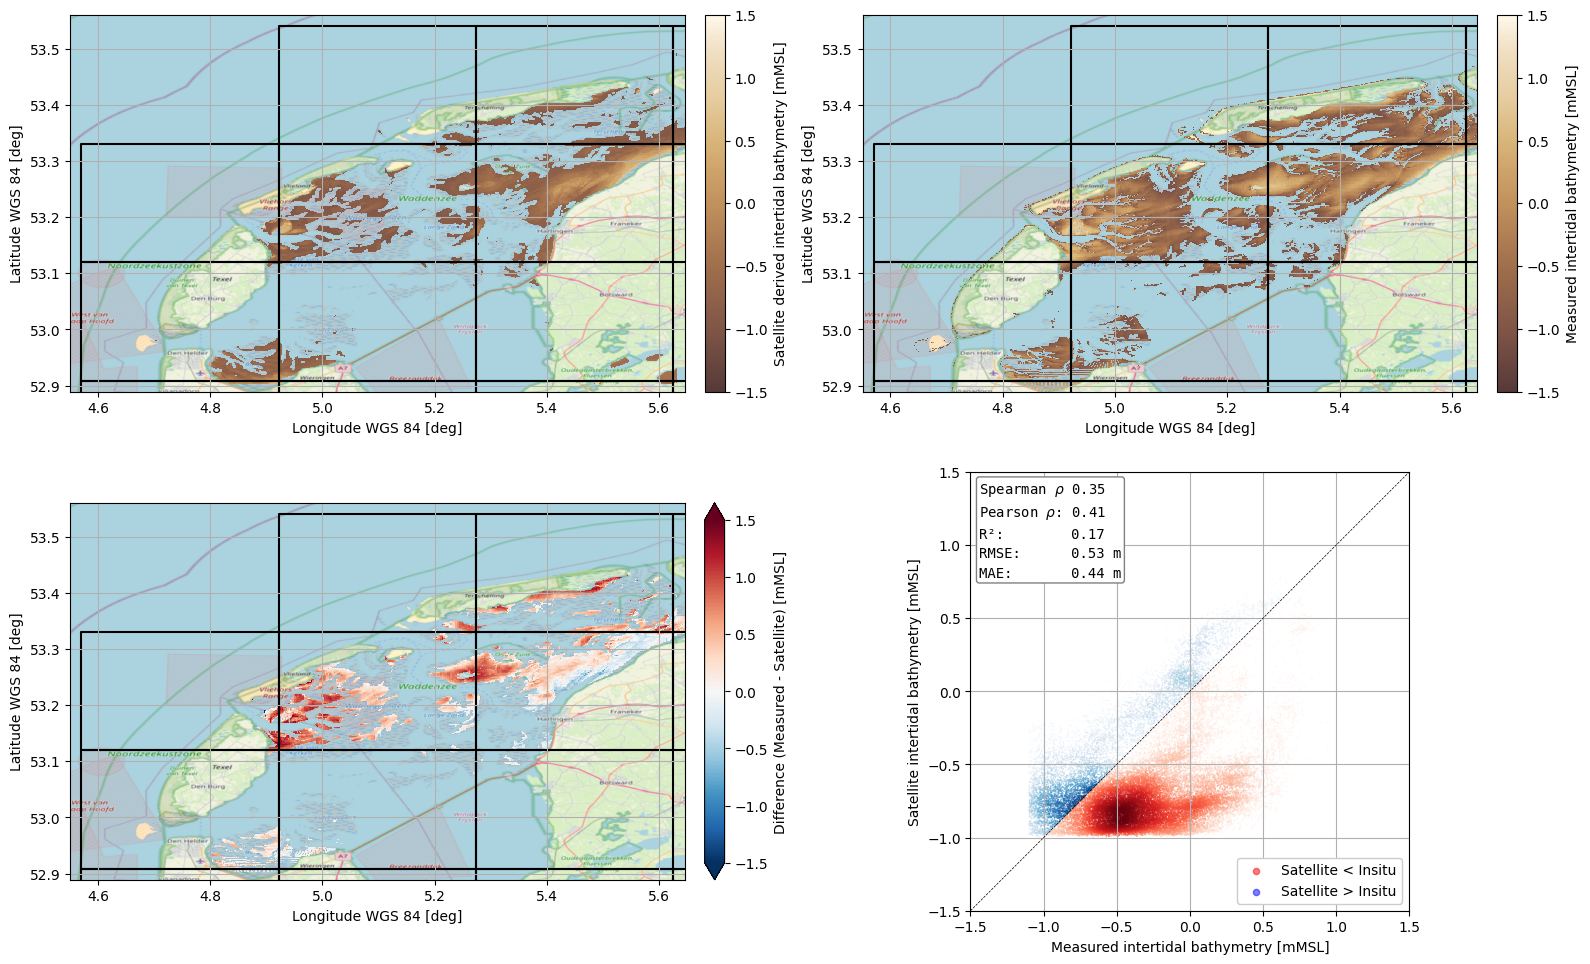

In [ ]:
vmin = -1.5
vmax = 1.5
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
rpc.imshow(ds_sdb_wz.isel(band=0), ax=axs[0], data_style='default', cbar_kwargs={'label': 'Satellite derived intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax, cmap=cmaps.brown_sable) 
rpc.imshow(ds_insitu_wz, ax=axs[1], data_style='default', cbar_kwargs={'label': 'Measured intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax, cmap=cmaps.brown_sable)
rpc.imshow(ds_diff_wz, ax=axs[2], data_style='default', cbar_kwargs={'label': 'Difference (Measured - Satellite) [m]'}, vmin=vmin, vmax=vmax, cmap='RdBu_r')
for ax in axs[0:3]:
    rpc.geometries(gdf_tiles_wz, ax=ax, geom_style='tiles')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='waddenzee')
plot_statistics(axs[3], zs_dict_wz, stat_dict_wz, vmin, vmax)
rpc.show(fig=fig)

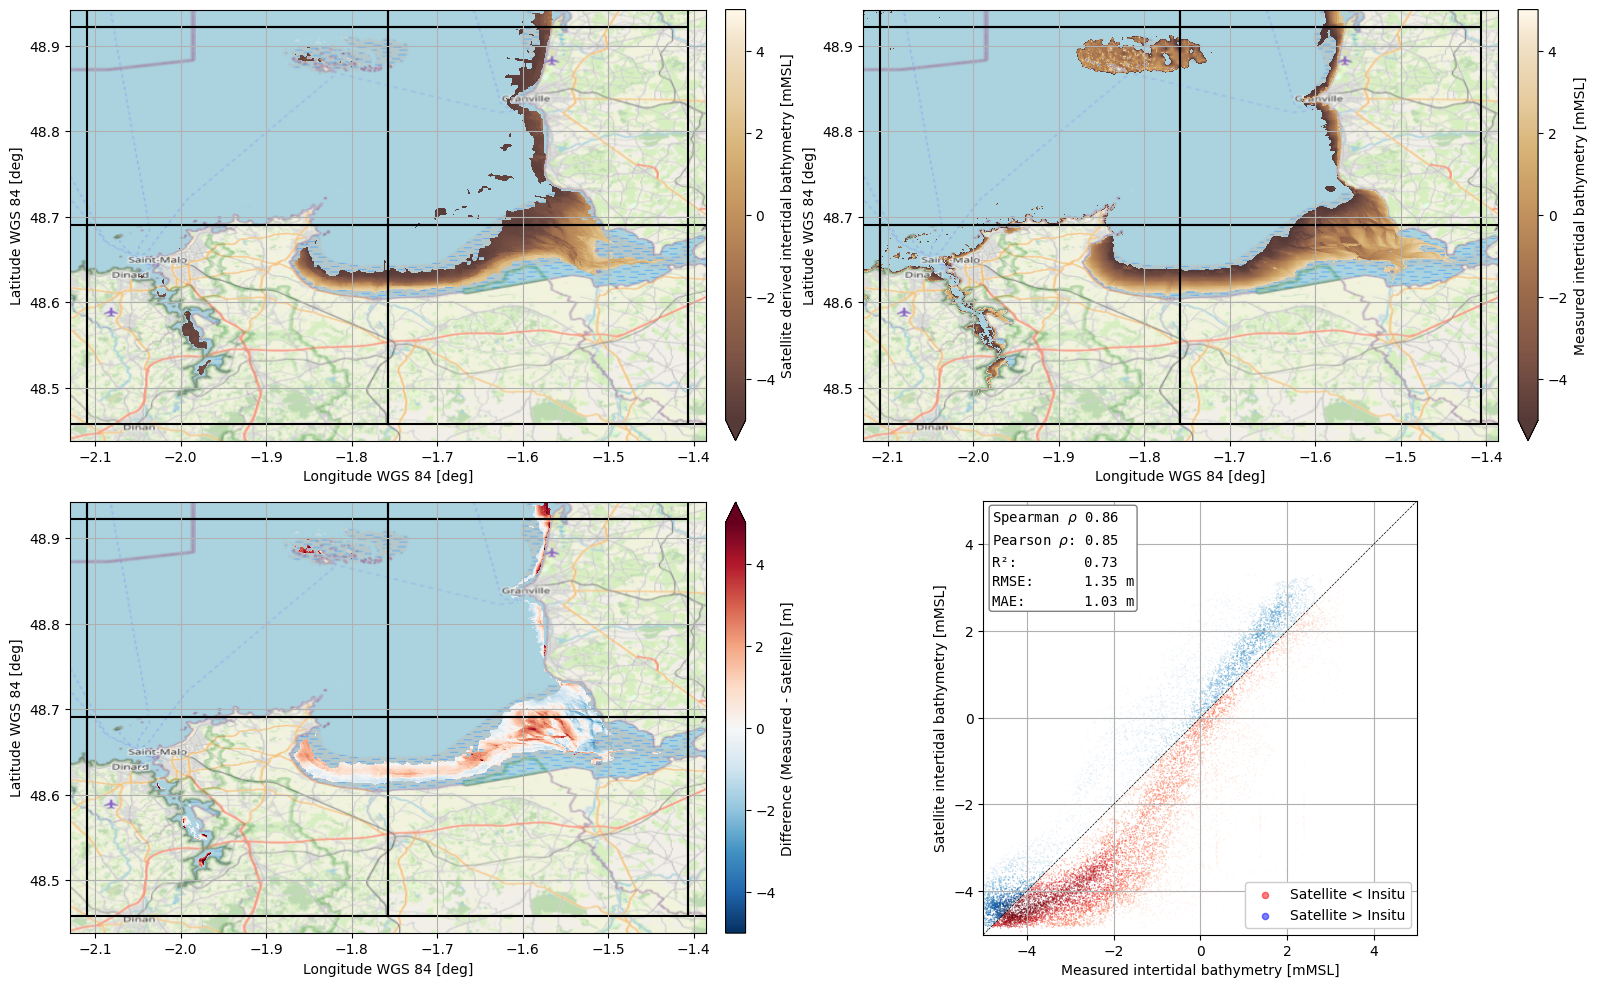

In [49]:
vmin = -5
vmax = 5
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
rpc.imshow(ds_sdb_ms.isel(band=0), ax=axs[0], data_style='default', cbar_kwargs={'label': 'Satellite derived intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax, cmap=cmaps.brown_sable) 
rpc.imshow(ds_insitu_ms, ax=axs[1], data_style='default', cbar_kwargs={'label': 'Measured intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax, cmap=cmaps.brown_sable)
rpc.imshow(ds_diff_ms, ax=axs[2], data_style='default', cbar_kwargs={'label': 'Difference (Measured - Satellite) [m]'}, vmin=vmin, vmax=vmax, cmap='RdBu_r')
for ax in axs[0:3]:
    rpc.geometries(gdf_tiles_ms, ax=ax, geom_style='tiles')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='le mont-saint-michel')
plot_statistics(axs[3], zs_dict_ms, stat_dict_ms, vmin, vmax)
rpc.show(fig=fig)

NameError: name 'ds_sdb_sb' is not defined

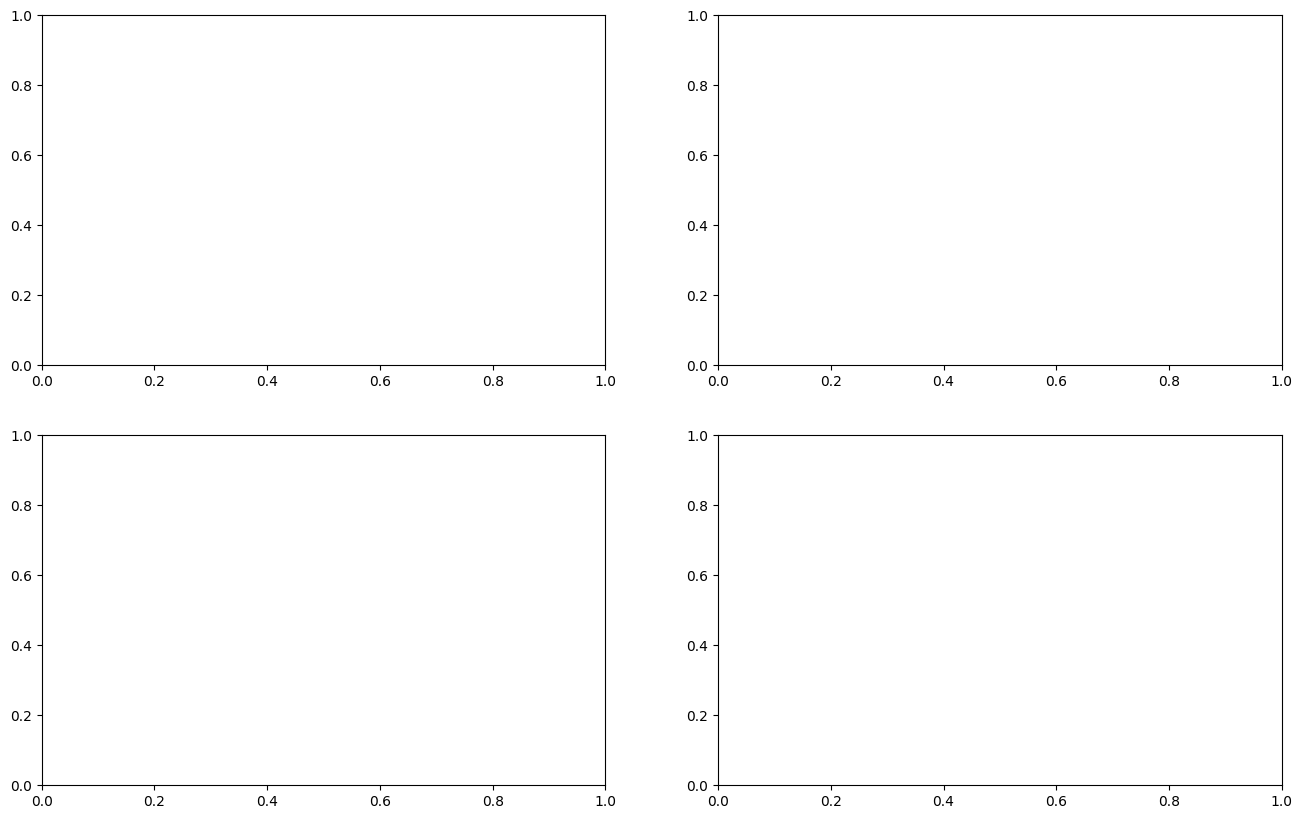

In [29]:
vmin = -5
vmax = 5
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
rpc.imshow(ds_sdb_sb.isel(band=0), ax=axs[0], data_style='default', cbar_kwargs={'label': 'Satellite intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax, cmap=cmaps.brown_sable)
rpc.imshow(ds_insitu_sb, ax=axs[1], data_style='default', cbar_kwargs={'label': 'Insitu intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax)
rpc.imshow(ds_diff_sb, ax=axs[2], data_style='default', cbar_kwargs={'label': 'Difference [m]'}, vmin=vmin, vmax=vmax, cmap='RdBu_r')
for ax in axs[0:3]:
    rpc.geometries(gdf_tiles_sb, ax=ax, geom_style='tiles')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='shark Bay')
plot_statistics(axs[3], zs_dict_sb, stat_dict_sb, vmin, vmax)
rpc.show(fig=fig)

In [ ]:
vmin = -1
vmax = 1
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
rpc.imshow(ds_sdb_bb.isel(band=0), ax=axs[0], data_style='default', cbar_kwargs={'label': 'Satellite intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax, cmap=cmaps.brown_sable)
rpc.imshow(ds_insitu_bb, ax=axs[1], data_style='default', cbar_kwargs={'label': 'Insitu intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax)
rpc.imshow(ds_diff_bb, ax=axs[2], data_style='default', cbar_kwargs={'label': 'Difference [m]'}, vmin=vmin, vmax=vmax, cmap='RdBu_r')
for ax in axs[0:3]:
    rpc.geometries(gdf_tiles_bb, ax=ax, geom_style='tiles')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='brisbane')
plot_statistics(axs[3], zs_dict_bb, stat_dict_bb, vmin, vmax)
rpc.show(fig=fig)

In [ ]:
vmin = -5
vmax = 5
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
rpc.imshow(ds_sdb_ku.isel(band=0), ax=axs[0], data_style='default', cbar_kwargs={'label': 'Satellite intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax, cmap=cmaps.brown_sable)
rpc.imshow(ds_insitu_ku, ax=axs[1], data_style='default', cbar_kwargs={'label': 'Insitu intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax)
rpc.imshow(ds_diff_ku, ax=axs[2], data_style='default', cbar_kwargs={'label': 'Difference [m]'}, vmin=vmin, vmax=vmax, cmap='RdBu_r')
for ax in axs[0:3]:
    rpc.geometries(gdf_tiles_ku, ax=ax, geom_style='tiles')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='karumba')
plot_statistics(axs[3], zs_dict_ku, stat_dict_ku, vmin, vmax)
rpc.show(fig=fig)

In [ ]:
vmin = -5
vmax = 5
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
rpc.imshow(ds_sdb_nl.isel(band=0), ax=axs[0], data_style='default', cbar_kwargs={'label': 'Satellite intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax, cmap=cmaps.brown_sable)
rpc.imshow(ds_insitu_nl, ax=axs[1], data_style='default', cbar_kwargs={'label': 'Insitu intertidal bathymetry [mMSL]'}, vmin=vmin, vmax=vmax)
rpc.imshow(ds_diff_nl, ax=axs[2], data_style='default', cbar_kwargs={'label': 'Difference [m]'}, vmin=vmin, vmax=vmax, cmap='RdBu_r')
for ax in axs[0:3]:
    rpc.geometries(gdf_tiles_nl, ax=ax, geom_style='tiles')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='netherlands')
plot_statistics(axs[3], zs_dict_nl, stat_dict_nl, vmin, vmax)
rpc.show(fig=fig)